In [11]:
# ============================================================
# CISB5123 Text Analytics – Lab Assignment 2
# Sentiment Analysis on Amazon Fine Food Reviews
# ============================================================
# Student Name : Muhammad Faris Irfan Bin Mohmad Natar, Faiq Arifbillah bin Syahrir
# Student ID   : IS01083410, IS01083886
# ============================================================
#
# Strengths and Weaknesses of Selected Models
# ---------------------------------------------------------
# Three models used for this assignment:
#
# 1. VADER (Lexicon-Based)
#    Strengths : Fast, requires no training data, handles social-media text
#                well (slang, emoticons, capitalisation), works out-of-the-box.
#    Weaknesses: Relies on a fixed lexicon so domain-specific terms (e.g. food
#                jargon) may be missed; struggles with sarcasm and context that
#                requires understanding of the whole sentence.
#
# 2. Naïve Bayes with TF-IDF (Machine-Learning Based)
#    Strengths : Simple, fast to train, performs well on text classification
#                even with limited data, naturally handles high-dimensional
#                feature spaces.
#    Weaknesses: Strong independence assumption between features is rarely true
#                in natural language; cannot capture word order or semantic
#                meaning; sensitive to class imbalance.
#
# 3. Logistic Regression with TF-IDF (Machine-Learning Based)
#    Strengths : Produces calibrated probability scores, generally outperforms
#                Naïve Bayes on text tasks, interpretable via feature weights,
#                regularisation (C parameter) helps prevent overfitting.
#    Weaknesses: Slower to train than Naïve Bayes on very large corpora;
#                still treats features as independent and ignores word order;
#                requires careful preprocessing to perform well.
#
# Overall, lexicon-based methods are ideal for quick, training-free sentiment
# estimation, while ML-based methods excel when labelled data is available and
# accuracy is the priority.
# ============================================================
 

In [12]:
import warnings
warnings.filterwarnings("ignore")
 
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, ConfusionMatrixDisplay
)
 
# Download required NLTK data
for pkg in ["stopwords", "wordnet", "vader_lexicon", "omw-1.4"]:
    nltk.download(pkg, quiet=True)
 
print("All imports successful.\n")
 

All imports successful.



In [13]:
CSV_PATH = "Reviews.csv" 

df = pd.read_csv(CSV_PATH)
print(f"Raw shape: {df.shape}")
print(df.head(3))
print("\nColumn dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nScore distribution:\n", df["Score"].value_counts().sort_index())

Raw shape: (568454, 10)
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1      Not as Advertised  Product arrived labeled as Jumbo Salted Peanut...  
2  "Delight" says it all  This is a confection that has been around a fe...  

Column dtypes:
 Id                         int64
ProductId                 object
UserId             

In [14]:
df.drop_duplicates(subset=["UserId", "ProfileName", "Time", "Text"], inplace=True)
df.dropna(subset=["Text", "Score"], inplace=True)
 
# Map Score, Sentiment label

def map_sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"
 
df["Sentiment"] = df["Score"].apply(map_sentiment)
print("Sentiment distribution:\n", df["Sentiment"].value_counts())
 
# Sample for faster experimentation (keep class balance via stratify)
#     Comment out the next 3 lines to run on the full dataset.
SAMPLE_SIZE = 30_000
df = df.groupby("Sentiment", group_keys=False).apply(
    lambda x: x.sample(min(len(x), SAMPLE_SIZE // 3), random_state=42)
).reset_index(drop=True)
print(f"\nAfter sampling: {df.shape}")
print("Sentiment counts:\n", df["Sentiment"].value_counts())
 
# Text cleaning function
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
 
def clean_text(text):
    """Lowercase, remove HTML/URLs/punctuation, lemmatise, remove stopwords."""
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)          # strip HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text)   # strip URLs
    text = re.sub(r"[^a-z\s]", " ", text)          # keep only letters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return " ".join(tokens)
 
print("\nCleaning text (this may take a moment)…")
df["CleanText"] = df["Text"].apply(clean_text)
print("Sample cleaned text:")
print(df[["Text", "CleanText"]].head(2).to_string())

Sentiment distribution:
 Positive    307056
Negative     57108
Neutral      29769
Name: Sentiment, dtype: int64

After sampling: (30000, 11)
Sentiment counts:
 Negative    10000
Neutral     10000
Positive    10000
Name: Sentiment, dtype: int64

Cleaning text (this may take a moment)…
Sample cleaned text:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                           Text                                                                                                                                                                                                                                       

In [15]:
X = df["CleanText"]
y = df["Sentiment"]
 
# Encode labels as integers for ROC-AUC
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
y_enc = y.map(label_map)
 
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
 
tfidf = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)
 
print(f"TF-IDF train shape : {X_train_tfidf.shape}")
print(f"TF-IDF test  shape : {X_test_tfidf.shape}")

TF-IDF train shape : (24000, 20000)
TF-IDF test  shape : (6000, 20000)


In [16]:
sid = SentimentIntensityAnalyzer()
 
def vader_predict(text):
    compound = sid.polarity_scores(str(text))["compound"]
    if compound >= 0.05:
        return 2   # Positive
    elif compound <= -0.05:
        return 0   # Negative
    else:
        return 1   # Neutral
 
# Run VADER on the raw (uncleaned) test text so it can use punctuation/caps
test_texts = df.loc[y_test.index, "Text"]
y_pred_vader = test_texts.apply(vader_predict).values
 
print("VADER Classification Report:")
print(classification_report(
    y_test, y_pred_vader,
    target_names=["Negative", "Neutral", "Positive"]
))
acc_vader = accuracy_score(y_test, y_pred_vader)
print(f"VADER Accuracy: {acc_vader:.4f}")

VADER Classification Report:
              precision    recall  f1-score   support

    Negative       0.64      0.40      0.50      2000
     Neutral       0.34      0.04      0.07      2000
    Positive       0.42      0.94      0.58      2000

    accuracy                           0.46      6000
   macro avg       0.47      0.46      0.38      6000
weighted avg       0.47      0.46      0.38      6000

VADER Accuracy: 0.4610


In [17]:
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)
 
print("Naïve Bayes Classification Report:")
print(classification_report(
    y_test, y_pred_nb,
    target_names=["Negative", "Neutral", "Positive"]
))
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naïve Bayes Accuracy: {acc_nb:.4f}")

Naïve Bayes Classification Report:
              precision    recall  f1-score   support

    Negative       0.67      0.68      0.68      2000
     Neutral       0.57      0.58      0.58      2000
    Positive       0.77      0.75      0.76      2000

    accuracy                           0.67      6000
   macro avg       0.67      0.67      0.67      6000
weighted avg       0.67      0.67      0.67      6000

Naïve Bayes Accuracy: 0.6707


In [18]:
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_tfidf, y_train)
y_pred_lr = lr.predict(X_test_tfidf)
 
print("Logistic Regression Classification Report:")
print(classification_report(
    y_test, y_pred_lr,
    target_names=["Negative", "Neutral", "Positive"]
))
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.70      0.70      2000
     Neutral       0.59      0.59      0.59      2000
    Positive       0.77      0.78      0.77      2000

    accuracy                           0.69      6000
   macro avg       0.69      0.69      0.69      6000
weighted avg       0.69      0.69      0.69      6000

Logistic Regression Accuracy: 0.6878


In [19]:
from sklearn.preprocessing import label_binarize
 
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
 
# VADER: convert predictions to one-hot for AUC
y_vader_bin = label_binarize(y_pred_vader, classes=[0, 1, 2])
 
# NB probabilities
nb_proba = nb.predict_proba(X_test_tfidf)
 
# LR probabilities
lr_proba = lr.predict_proba(X_test_tfidf)
 
def safe_roc_auc(y_true_bin, y_score):
    try:
        return roc_auc_score(y_true_bin, y_score, multi_class="ovr", average="macro")
    except Exception:
        return float("nan")
 
auc_vader = safe_roc_auc(y_test_bin, y_vader_bin)
auc_nb    = safe_roc_auc(y_test_bin, nb_proba)
auc_lr    = safe_roc_auc(y_test_bin, lr_proba)
 
summary = pd.DataFrame({
    "Model":    ["VADER (Lexicon)", "Naïve Bayes (TF-IDF)", "Logistic Regression (TF-IDF)"],
    "Accuracy": [acc_vader, acc_nb, acc_lr],
    "ROC-AUC":  [auc_vader, auc_nb, auc_lr],
    "Type":     ["Lexicon-Based", "ML-Based", "ML-Based"],
})
print(summary.to_string(index=False))

                       Model  Accuracy  ROC-AUC          Type
             VADER (Lexicon)  0.461000 0.595750 Lexicon-Based
        Naïve Bayes (TF-IDF)  0.670667 0.843546      ML-Based
Logistic Regression (TF-IDF)  0.687833 0.857013      ML-Based


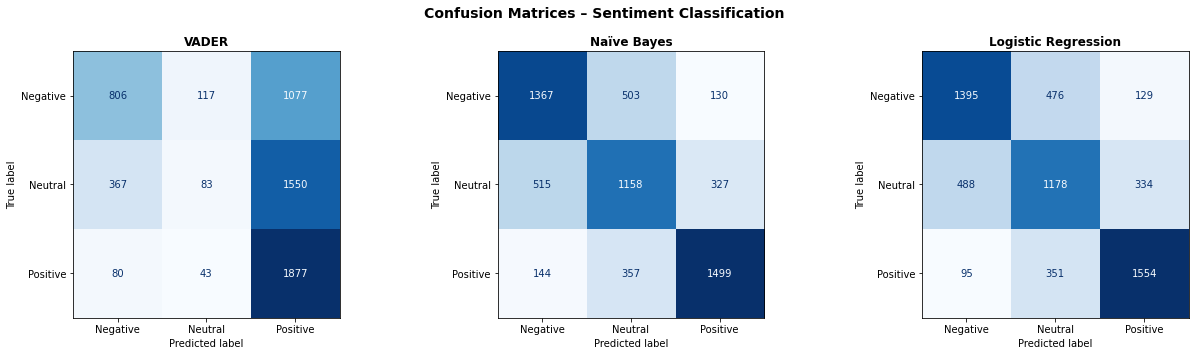

Saved: confusion_matrices.png


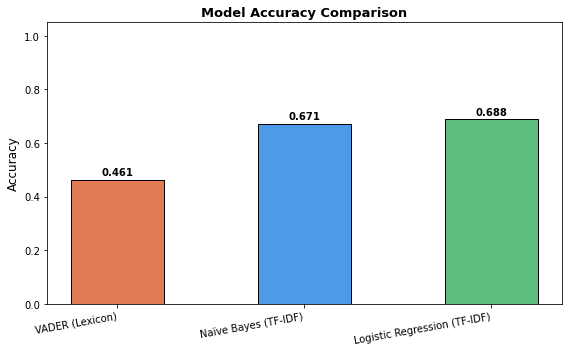

Saved: accuracy_comparison.png


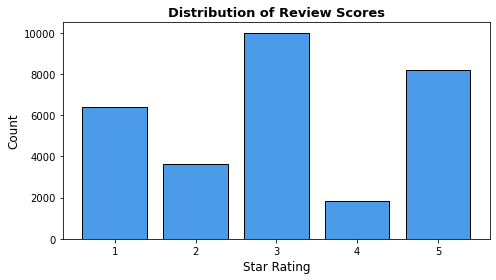

Saved: score_distribution.png


In [20]:
label_names = ["Negative", "Neutral", "Positive"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Confusion Matrices – Sentiment Classification", fontsize=14, fontweight="bold")
 
for ax, (name, y_pred) in zip(axes, [
    ("VADER",                y_pred_vader),
    ("Naïve Bayes",          y_pred_nb),
    ("Logistic Regression",  y_pred_lr),
]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=12, fontweight="bold")
 
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")
 
# Accuracy bar chart
fig2, ax2 = plt.subplots(figsize=(8, 5))
colors = ["#E07B54", "#4C9BE8", "#5DBE7E"]
bars = ax2.bar(summary["Model"], summary["Accuracy"], color=colors, edgecolor="black", width=0.5)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("Accuracy", fontsize=12)
ax2.set_title("Model Accuracy Comparison", fontsize=13, fontweight="bold")
ax2.set_xticklabels(summary["Model"], rotation=10, ha="right")
for bar, val in zip(bars, summary["Accuracy"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: accuracy_comparison.png")
 
# Score distribution of original dataset
fig3, ax3 = plt.subplots(figsize=(7, 4))
score_counts = df["Score"].value_counts().sort_index()
ax3.bar(score_counts.index, score_counts.values, color="#4C9BE8", edgecolor="black")
ax3.set_xlabel("Star Rating", fontsize=12)
ax3.set_ylabel("Count", fontsize=12)
ax3.set_title("Distribution of Review Scores", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: score_distribution.png")

In [21]:
export_df = df[["Id", "Score", "Summary", "Text", "CleanText", "Sentiment"]].copy()
export_df.to_csv("amazon_sentiment_processed.csv", index=False)
print(f"Exported {len(export_df)} rows → amazon_sentiment_processed.csv")

Exported 30000 rows → amazon_sentiment_processed.csv
